# Latest GW Player Picker Dashboard

Use this notebook to shortlist players by position, inspect predicted points, and generate plots you can share with your league group.

In [14]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.append(str(Path('../..').resolve()))
from latest_gw_tools import load_latest_outputs, load_gw_outputs
from squad_selection import get_best_11, get_best_11_noadj, get_owner_dict

sns.set_theme(style='whitegrid')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)

In [15]:
# Leave TARGET_GW as None to auto-load latest available GW output.
TARGET_GW = 3
TOP_N = 20
BACKTEST_YEAR = 26
EXPORT_FIGURES = False
FIG_DIR = Path('..') / 'figures'

if EXPORT_FIGURES:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

In [16]:
if TARGET_GW is None:
    latest_gw, pred_simple, pred_full, fixture_difficulty = load_latest_outputs(predictions_dir='../predictions', fixture_dir='../fixture_difficulty')
else:
    latest_gw = TARGET_GW
    pred_simple, pred_full, fixture_difficulty = load_gw_outputs(TARGET_GW, predictions_dir='../predictions', fixture_dir='../fixture_difficulty')

print(f'Loaded GW: {latest_gw}')
print(f'Players in simple output: {len(pred_simple):,}')
print(f'Players in full output: {len(pred_full):,}')

Loaded GW: 3
Players in simple output: 627
Players in full output: 627


In [39]:
df = pred_simple.copy()
if 'predicted_points_adj' not in df.columns:
    df['predicted_points_adj'] = df['predicted_points']

owner_dict = get_owner_dict()
owner_name_map = {str(int(k)): v for k, v in owner_dict.items()}
df['owner_name'] = df['owner'].fillna(-1).astype(int).astype(str).map(owner_name_map).fillna('Free Agent')

# Combine duplicate player rows (e.g., double gameweeks) into one row per player/team/position/owner.
group_cols = ['full_name', 'team', 'position', 'owner_name']
for col in ['predicted_points', 'predicted_points_adj', 'fixture_diff_index']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

agg_dict = {
    'predicted_points': 'sum',
    'predicted_points_adj': 'sum',
}
if 'fixture_diff_index' in df.columns:
    agg_dict['fixture_diff_index'] = 'mean'

df = (
    df.groupby(group_cols, as_index=False)
    .agg(agg_dict)
)

# --- Multi-GW horizon means: mean predicted points (adjusted) over the next 3/6
# GWs starting at latest_gw. A blank GW for a player is excluded from their
# average (not counted as zero) -- matches the horizon methodology in WORKFLOW.md.
predictions_dir = Path('..') / 'predictions'

def load_horizon_mean_adj(start_gw, n_gws, predictions_dir=predictions_dir):
    frames = []
    for gw in range(start_gw, start_gw + n_gws):
        path = predictions_dir / f'predicted_gw{gw}_simple.csv'
        if not path.exists():
            break
        gw_df = pd.read_csv(path)
        if 'predicted_points_adj' not in gw_df.columns:
            gw_df['predicted_points_adj'] = gw_df['predicted_points']
        # Combine double-gameweek duplicates within this GW before averaging across GWs.
        gw_df = (
            gw_df.groupby(['full_name', 'team', 'position'], as_index=False)
            [['predicted_points_adj']].sum()
        )
        frames.append(gw_df)
    if not frames:
        return pd.DataFrame(columns=['full_name', 'team', 'position', 'predicted_points_adj'])
    return (
        pd.concat(frames, ignore_index=True)
        .groupby(['full_name', 'team', 'position'], as_index=False)
        .mean(numeric_only=True)
    )

horizon_3gw = load_horizon_mean_adj(latest_gw, 3).rename(columns={'predicted_points_adj': 'predicted_points_adj_3gw'})
horizon_6gw = load_horizon_mean_adj(latest_gw, 6).rename(columns={'predicted_points_adj': 'predicted_points_adj_6gw'})

df = df.merge(horizon_3gw, on=['full_name', 'team', 'position'], how='left')
df = df.merge(horizon_6gw, on=['full_name', 'team', 'position'], how='left')

rank_col = 'predicted_points'
df_sorted = df.sort_values(rank_col, ascending=False).reset_index(drop=True)
df_sorted.head(50)

,full_name,team,position,owner_name,predicted_points,predicted_points_adj,fixture_diff_index,predicted_points_adj_3gw,predicted_points_adj_6gw
0,bruno_borges_fernandes,Man Utd,MID,Lucas,7.028292,7.283995,1.036382,8.920713,8.611228
1,erling_haaland,Man City,FWD,Rory D,5.973687,6.891915,1.153712,9.849672,9.050447
2,joao_pedro_junqueira_de_jesus,Chelsea,FWD,Tobias,5.954611,7.696663,1.292555,9.177904,9.491910
3,cole_palmer,Chelsea,MID,Richard,5.203419,3.975260,0.763971,4.275992,6.156497
4,bryan_mbeumo,Man Utd,MID,Rory B,5.174199,5.362447,1.036382,6.569092,6.335679
5,gabriel_dos_santos_magalhaes,Arsenal,DEF,Doug,5.134538,6.505444,1.266997,6.989424,8.453847
6,morgan_rogers,Chelsea,MID,Dave,5.031000,3.843537,0.763971,4.134150,5.951355
7,bukayo_saka,Arsenal,MID,Arthur,4.930232,8.520015,1.728116,6.747308,6.367934
8,iliman_ndiaye,Everton,MID,Lucas,4.914721,3.538381,0.719956,5.718255,4.756260
9,antoine_semenyo,Man City,MID,Dave,4.796598,7.766188,1.619104,6.026175,7.597857


In [18]:
## Position Shortlists

In [19]:
show_cols = ['full_name', 'team', 'owner_name', 'predicted_points', 'predicted_points_adj',
             'predicted_points_adj_3gw', 'predicted_points_adj_6gw', 'fixture_diff_index']
position_lists = {}

for pos in ['GK', 'DEF', 'MID', 'FWD']:
    pos_df = (
        df_sorted
        .query('position == @pos')
        .loc[:, show_cols]
        .head(TOP_N)
        .reset_index(drop=True)
    )
    position_lists[pos] = pos_df
    print(f'\nTop {TOP_N} {pos}')
    display(pos_df)


Top 20 GK


,full_name,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,david_raya_martin,Arsenal,Doug,4.412463,4.706627,6.422321,7.136416,1.066667
1,gianluigi_donnarumma,Man City,Lucas,4.109209,8.218418,6.232632,4.959684,2.000000
2,james_trafford,Leeds,Arthur,3.620601,5.792961,5.933282,6.297530,1.600000
3,konstantinos_tzolakis,Hull City,Free Agent,3.458100,6.916200,7.482761,7.509809,2.000000
4,carl_rushworth,Coventry City,Will,3.446949,1.723474,2.276666,2.735642,0.500000
5,caoimhin_kelleher,Brentford,Dave,3.427406,6.854812,5.504494,4.963536,2.000000
6,jordan_pickford,Everton,Marcus,3.369215,6.738430,5.514258,4.781400,2.000000
7,senne_lammens,Man Utd,Dave,3.288020,2.192014,2.401891,2.800881,0.666667
8,robin_roefs,Sunderland,Rory D,3.224013,5.015132,3.824346,4.006328,1.555556
9,matz_sels,Nott'm Forest,Arthur,3.097835,5.782626,5.644944,3.913667,1.866667



Top 20 DEF


,full_name,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,gabriel_dos_santos_magalhaes,Arsenal,Doug,5.134538,6.505444,6.989424,8.453847,1.266997
1,riccardo_calafiori,Arsenal,Richard,4.617613,5.850502,6.272366,7.578393,1.266997
2,ruben_dos_santos_gato_alves_dias,Man City,Rory B,4.228948,8.457896,7.910246,7.097640,2.000000
3,maxence_lacroix,Chelsea,Rory D,4.102346,2.051173,2.466773,3.983048,0.500000
4,nathan_collins,Brentford,Doug,4.074061,8.148122,6.820824,7.482669,2.000000
5,james_tarkowski,Everton,Marcus,4.068403,8.136806,7.506363,6.730578,2.000000
6,kristoffer_ajer,Brentford,Free Agent,4.042409,8.084818,6.768212,7.424740,2.000000
7,jarrad_branthwaite,Everton,Tobias,4.023090,8.046181,7.420704,6.654210,2.000000
8,benjamin_white,Arsenal,Will,4.002366,5.070986,5.418919,6.536422,1.266997
9,james_hill,Bournemouth,Lucas,3.784102,1.892051,2.564743,3.342224,0.500000



Top 20 MID


,full_name,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,bruno_borges_fernandes,Man Utd,Lucas,7.028292,7.283995,8.920713,8.611228,1.036382
1,cole_palmer,Chelsea,Richard,5.203419,3.975260,4.275992,6.156497,0.763971
2,bryan_mbeumo,Man Utd,Rory B,5.174199,5.362447,6.569092,6.335679,1.036382
3,morgan_rogers,Chelsea,Dave,5.031000,3.843537,4.134150,5.951355,0.763971
4,bukayo_saka,Arsenal,Arthur,4.930232,8.520015,6.747308,6.367934,1.728116
5,iliman_ndiaye,Everton,Lucas,4.914721,3.538381,5.718255,4.756260,0.719956
6,antoine_semenyo,Man City,Dave,4.796598,7.766188,6.026175,7.597857,1.619104
7,dominik_szoboszlai,Liverpool,Rory D,4.643936,8.647024,6.984785,5.698224,1.862003
8,rayan_cherki,Man City,Marcus,4.499289,7.284815,5.655516,7.130945,1.619104
9,mamadou_sangare,Brentford,Rory D,4.449493,5.064501,5.868334,6.195953,1.138220



Top 20 FWD


,full_name,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,erling_haaland,Man City,Rory D,5.973687,6.891915,9.849672,9.050447,1.153712
1,joao_pedro_junqueira_de_jesus,Chelsea,Tobias,5.954611,7.696663,9.177904,9.491910,1.292555
2,alexander_isak,Liverpool,Marcus,4.560513,6.030055,5.889297,6.163697,1.322232
3,dominic_calvert_lewin,Leeds,Arthur,4.319232,8.638465,6.592594,5.803632,2.000000
4,kai_havertz,Arsenal,Doug,4.258060,4.677141,5.280334,4.114888,1.098421
5,yoane_wissa,Newcastle,Will,4.173413,3.639115,4.177938,5.126817,0.871976
6,igor_thiago_nascimento_rodrigues,Brentford,Rory B,3.937328,2.048566,2.031811,1.993509,0.520294
7,oli_mcburnie,Hull City,Tobias,3.903781,1.951890,2.374257,3.003903,0.500000
8,igor_jesus_maciel_da_cruz,Nott'm Forest,Richard,3.795178,2.267701,2.020960,2.417230,0.597522
9,francisco_evanilson_de_lima_barbosa,Bournemouth,Richard,3.468077,1.937733,3.353909,4.169620,0.558734


In [20]:
show_cols = ['full_name', 'team', 'position', 'owner_name', 'predicted_points', 'predicted_points_adj',
             'predicted_points_adj_3gw', 'predicted_points_adj_6gw', 'fixture_diff_index']
positions = ['GK', 'DEF', 'MID', 'FWD']

for pos in positions:
    doug_pos = (
        df_sorted
        .query('position == @pos and owner_name == "Doug"')
        .loc[:, show_cols]
    )

    free_agent_pos = (
        df_sorted
        .query('position == @pos and owner_name == "Free Agent"')
        .loc[:, show_cols]
        .head(20)
    )

    combined_pos = pd.concat([doug_pos, free_agent_pos], ignore_index=True)

    print(f'\n{pos}: Doug + Top Free Agents')
    display(combined_pos)



GK: Doug + Top Free Agents


,full_name,team,position,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,david_raya_martin,Arsenal,GK,Doug,4.412463,4.706627,6.422321,7.136416,1.066667
1,lukas_hornicek,Newcastle,GK,Doug,2.681625,5.363251,4.210582,4.616016,2.000000
2,konstantinos_tzolakis,Hull City,GK,Free Agent,3.458100,6.916200,7.482761,7.509809,2.000000
3,robert_lynch_sanchez,Chelsea,GK,Free Agent,2.196140,1.171275,1.377843,1.837636,0.533333
4,kjell_scherpen,Ipswich Town,GK,Free Agent,2.122060,1.061030,1.750513,2.065462,0.500000
5,kepa_arrizabalaga_revuelta,Arsenal,GK,Free Agent,1.068059,1.139263,1.219915,1.190809,1.066667
6,illan_meslier,Arsenal,GK,Free Agent,1.068059,1.139263,1.219915,1.190809,1.066667
7,filip_jorgensen,Chelsea,GK,Free Agent,0.958023,0.510946,0.570774,0.617861,0.533333
8,marco_bizot,Aston Villa,GK,Free Agent,0.826795,0.413398,0.510400,0.488222,0.500000
9,mike_penders,Chelsea,GK,Free Agent,0.811133,0.432604,0.475023,0.473147,0.533333



DEF: Doug + Top Free Agents


,full_name,team,position,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,gabriel_dos_santos_magalhaes,Arsenal,DEF,Doug,5.134538,6.505444,6.989424,8.453847,1.266997
1,nathan_collins,Brentford,DEF,Doug,4.074061,8.148122,6.820824,7.482669,2.000000
2,nico_o'reilly,Man City,DEF,Doug,3.557839,7.115678,6.684786,5.995190,2.000000
3,nikola_milenkovic,Nott'm Forest,DEF,Doug,3.535401,7.070803,7.070803,5.329155,2.000000
4,abdukodir_khusanov,Man City,DEF,Doug,3.187638,6.375277,6.008792,5.387051,2.000000
5,kristoffer_ajer,Brentford,DEF,Free Agent,4.042409,8.084818,6.768212,7.424740,2.000000
6,antonio_joao_pereira_de_albuquerque_tavares_da...,Bournemouth,DEF,Free Agent,3.448254,1.724127,2.336317,3.046796,0.500000
7,john_egan,Hull City,DEF,Free Agent,3.239090,6.478180,4.877520,5.779628,2.000000
8,vitalii_mykolenko,Everton,DEF,Free Agent,3.026683,6.053367,5.537106,4.974898,2.000000
9,sven_botman,Newcastle,DEF,Free Agent,2.823094,5.646189,5.435082,5.481239,2.000000



MID: Doug + Top Free Agents


,full_name,team,position,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,diego_gomez_amarilla,Brighton,MID,Doug,4.292482,6.186815,6.077495,6.984959,1.441314
1,vitaly_janelt,Brentford,MID,Doug,3.787500,4.311007,5.002469,5.277653,1.138220
2,marcus_rashford,Man Utd,MID,Doug,3.698595,3.833157,4.697523,4.524653,1.036382
3,martin_odegaard,Arsenal,MID,Doug,3.292850,5.690428,4.494395,4.230715,1.728116
4,emiliano_buendia_stati,Aston Villa,MID,Doug,3.155186,1.577593,1.609864,1.600490,0.500000
5,victor_munoz,Liverpool,MID,Free Agent,3.729593,6.944514,5.602866,4.576029,1.862003
6,josh_king,Fulham,MID,Free Agent,3.615696,3.648843,2.914601,2.831884,1.009167
7,julio_enciso,Ipswich Town,MID,Free Agent,3.493867,4.508618,4.116001,3.933145,1.290438
8,harrison_armstrong,Everton,MID,Free Agent,3.360900,2.419699,3.891547,3.242467,0.719956
9,keane_lewis_potter,Brentford,MID,Free Agent,3.339162,3.800701,4.416058,4.655731,1.138220



FWD: Doug + Top Free Agents


,full_name,team,position,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,kai_havertz,Arsenal,FWD,Doug,4.258060,4.677141,5.280334,4.114888,1.098421
1,omar_marmoush,Spurs,FWD,Doug,2.618976,1.451672,1.392842,1.547683,0.554290
2,georginio_rutter,Brighton,FWD,Doug,1.611861,1.131830,1.186362,1.685252,0.702188
3,taiwo_awoniyi,Coventry City,FWD,Free Agent,3.011640,1.505820,1.974049,2.149239,0.500000
4,brian_brobbey,Sunderland,FWD,Free Agent,2.603747,4.800322,3.336214,3.196147,1.843621
5,charalampos_kostoulas,Brighton,FWD,Free Agent,2.537398,1.781730,1.871223,2.673222,0.702188
6,brandon_thomas_asante,Coventry City,FWD,Free Agent,2.340318,1.170159,1.526164,1.664497,0.500000
7,chuba_akpom,Ipswich Town,FWD,Free Agent,2.211864,2.544841,3.471404,3.579427,1.150541
8,jorgen_strand_larsen,Crystal Palace,FWD,Free Agent,2.075365,2.547138,1.692831,1.558809,1.227320
9,emersonn_correia_da_silva,Ipswich Town,FWD,Free Agent,1.976219,2.273721,3.105625,3.201669,1.150541


In [21]:
# A compact shortlist view you can screenshot/share.
shortlist = pd.concat(
    [
        position_lists[pos].assign(position=pos)
        for pos in ['GK', 'DEF', 'MID', 'FWD']
    ],
    ignore_index=True,
)

shortlist = shortlist[[
    'position', 'full_name', 'team', 'owner_name',
    'predicted_points', 'predicted_points_adj',
    'predicted_points_adj_3gw', 'predicted_points_adj_6gw',
    'fixture_diff_index'
 ]]
shortlist.head(40)

,position,full_name,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,GK,david_raya_martin,Arsenal,Doug,4.412463,4.706627,6.422321,7.136416,1.066667
1,GK,gianluigi_donnarumma,Man City,Lucas,4.109209,8.218418,6.232632,4.959684,2.000000
2,GK,james_trafford,Leeds,Arthur,3.620601,5.792961,5.933282,6.297530,1.600000
3,GK,konstantinos_tzolakis,Hull City,Free Agent,3.458100,6.916200,7.482761,7.509809,2.000000
4,GK,carl_rushworth,Coventry City,Will,3.446949,1.723474,2.276666,2.735642,0.500000
5,GK,caoimhin_kelleher,Brentford,Dave,3.427406,6.854812,5.504494,4.963536,2.000000
6,GK,jordan_pickford,Everton,Marcus,3.369215,6.738430,5.514258,4.781400,2.000000
7,GK,senne_lammens,Man Utd,Dave,3.288020,2.192014,2.401891,2.800881,0.666667
8,GK,robin_roefs,Sunderland,Rory D,3.224013,5.015132,3.824346,4.006328,1.555556
9,GK,matz_sels,Nott'm Forest,Arthur,3.097835,5.782626,5.644944,3.913667,1.866667


In [22]:
## Team Selection Helpers

In [23]:
formation_adj, best_11_adj = get_best_11(df_sorted)
formation_raw, best_11_raw = get_best_11_noadj(df_sorted)

print(f'Best XI (adj) formation: {formation_adj}')
display(best_11_adj[['full_name', 'position', 'team', 'owner_name', 'predicted_points', 'predicted_points_adj']])

print(f'Best XI (raw) formation: {formation_raw}')
display(best_11_raw[['full_name', 'position', 'team', 'owner_name', 'predicted_points']])

Best XI (adj) formation: {'GK': 1, 'DEF': 5, 'MID': 4, 'FWD': 1}


,full_name,position,team,owner_name,predicted_points,predicted_points_adj
6,dominik_szoboszlai,MID,Liverpool,Rory D,4.643936,8.647024
10,dominic_calvert_lewin,FWD,Leeds,Arthur,4.319232,8.638465
7,bukayo_saka,MID,Arsenal,Arthur,4.930232,8.520015
1,ruben_dos_santos_gato_alves_dias,DEF,Man City,Rory B,4.228948,8.457896
8,cody_gakpo,MID,Liverpool,Rory D,4.441138,8.269415
0,gianluigi_donnarumma,GK,Man City,Lucas,4.109209,8.218418
2,nathan_collins,DEF,Brentford,Doug,4.074061,8.148122
3,james_tarkowski,DEF,Everton,Marcus,4.068403,8.136806
4,kristoffer_ajer,DEF,Brentford,Free Agent,4.042409,8.084818
5,jarrad_branthwaite,DEF,Everton,Tobias,4.023090,8.046181


Best XI (raw) formation: {'GK': 1, 'DEF': 3, 'MID': 5, 'FWD': 2}


,full_name,position,team,owner_name,predicted_points
4,bruno_borges_fernandes,MID,Man Utd,Lucas,7.028292
9,erling_haaland,FWD,Man City,Rory D,5.973687
10,joao_pedro_junqueira_de_jesus,FWD,Chelsea,Tobias,5.954611
5,cole_palmer,MID,Chelsea,Richard,5.203419
6,bryan_mbeumo,MID,Man Utd,Rory B,5.174199
1,gabriel_dos_santos_magalhaes,DEF,Arsenal,Doug,5.134538
7,morgan_rogers,MID,Chelsea,Dave,5.031000
8,bukayo_saka,MID,Arsenal,Arthur,4.930232
2,riccardo_calafiori,DEF,Arsenal,Richard,4.617613
0,david_raya_martin,GK,Arsenal,Doug,4.412463


In [24]:
doug_pool = df_sorted.query('owner_name == "Doug"').copy()
doug_formation, doug_best_11 = get_best_11(doug_pool)

print(f"Doug Best XI formation: {doug_formation['DEF']}-{doug_formation['MID']}-{doug_formation['FWD']}")
display(
    doug_best_11[
        ['full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'fixture_diff_index']
    ].sort_values(['position', 'predicted_points_adj'], ascending=[True, False]).reset_index(drop=True)
)

bench_key_cols = ['full_name', 'team', 'position']
bench_keys = set(
    tuple(row) for row in doug_best_11[bench_key_cols].drop_duplicates().itertuples(index=False, name=None)
)
bench_players = (
    doug_pool[
        ~doug_pool[bench_key_cols].apply(tuple, axis=1).isin(bench_keys)
    ][['full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'fixture_diff_index']]
    .sort_values('predicted_points_adj', ascending=False)
    .reset_index(drop=True)
)

print('Doug Bench Players:')
display(bench_players)

Doug Best XI formation: 5-4-1


,full_name,position,team,predicted_points,predicted_points_adj,fixture_diff_index
0,nathan_collins,DEF,Brentford,4.074061,8.148122,2.000000
1,nico_o'reilly,DEF,Man City,3.557839,7.115678,2.000000
2,nikola_milenkovic,DEF,Nott'm Forest,3.535401,7.070803,2.000000
3,gabriel_dos_santos_magalhaes,DEF,Arsenal,5.134538,6.505444,1.266997
4,abdukodir_khusanov,DEF,Man City,3.187638,6.375277,2.000000
5,kai_havertz,FWD,Arsenal,4.258060,4.677141,1.098421
6,lukas_hornicek,GK,Newcastle,2.681625,5.363251,2.000000
7,diego_gomez_amarilla,MID,Brighton,4.292482,6.186815,1.441314
8,martin_odegaard,MID,Arsenal,3.292850,5.690428,1.728116
9,vitaly_janelt,MID,Brentford,3.787500,4.311007,1.138220


Doug Bench Players:


,full_name,position,team,predicted_points,predicted_points_adj,fixture_diff_index
0,david_raya_martin,GK,Arsenal,4.412463,4.706627,1.066667
1,emiliano_buendia_stati,MID,Aston Villa,3.155186,1.577593,0.500000
2,omar_marmoush,FWD,Spurs,2.618976,1.451672,0.554290
3,georginio_rutter,FWD,Brighton,1.611861,1.131830,0.702188


In [25]:
owner_summary_rows = []
fa_formation = None
fa_best_11 = pd.DataFrame()

for owner_name in sorted(df_sorted['owner_name'].unique()):
    if owner_name == 'Free Agent':
        continue
    owner_df = df_sorted.query('owner_name == @owner_name').copy()
    if owner_df.empty:
        continue
    owner_formation, owner_best_11 = get_best_11(owner_df)
    owner_summary_rows.append({
        'owner_name': owner_name,
        'formation': f"{owner_formation['DEF']}-{owner_formation['MID']}-{owner_formation['FWD']}",
        'predicted_points_adj_sum': owner_best_11['predicted_points_adj'].sum(),
        'predicted_points_sum': owner_best_11['predicted_points'].sum(),
    })

# Add and show the best XI that can be built from free agents only.
free_agent_df = df_sorted.query('owner_name == "Free Agent"').copy()
if not free_agent_df.empty:
    fa_formation, fa_best_11 = get_best_11(free_agent_df)
    owner_summary_rows.append({
        'owner_name': 'Free Agent XI',
        'formation': f"{fa_formation['DEF']}-{fa_formation['MID']}-{fa_formation['FWD']}",
        'predicted_points_adj_sum': fa_best_11['predicted_points_adj'].sum(),
        'predicted_points_sum': fa_best_11['predicted_points'].sum(),
    })

owner_summary = pd.DataFrame(owner_summary_rows).sort_values('predicted_points_adj_sum', ascending=False)
display(owner_summary)

if fa_best_11.empty:
    print('No Free Agent XI available for this GW.')
else:
    print(f"Free Agent XI formation: {fa_formation['DEF']}-{fa_formation['MID']}-{fa_formation['FWD']}")
    display(
        fa_best_11[
            ['full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'fixture_diff_index']
        ].sort_values(['position', 'predicted_points_adj'], ascending=[True, False]).reset_index(drop=True)
    )

,owner_name,formation,predicted_points_adj_sum,predicted_points_sum
2,Doug,5-4-1,65.277123,41.500589
10,Free Agent XI,5-4-1,64.469807,35.031261
4,Marcus,3-5-2,61.388793,41.069148
7,Rory D,5-4-1,54.291393,41.547347
9,Will,4-4-2,52.690523,37.678517
0,Arthur,4-4-2,45.880734,32.809577
8,Tobias,4-4-2,44.960887,40.444881
1,Dave,5-4-1,43.683657,32.657523
6,Rory B,3-4-3,42.499748,31.676083
3,Lucas,4-5-1,42.279705,39.660379


Free Agent XI formation: 5-4-1


,full_name,position,team,predicted_points,predicted_points_adj,fixture_diff_index
0,kristoffer_ajer,DEF,Brentford,4.042409,8.084818,2.000000
1,john_egan,DEF,Hull City,3.239090,6.478180,2.000000
2,vitalii_mykolenko,DEF,Everton,3.026683,6.053367,2.000000
3,sven_botman,DEF,Newcastle,2.823094,5.646189,2.000000
4,amar_dedic,DEF,Newcastle,2.617272,5.234544,2.000000
5,brian_brobbey,FWD,Sunderland,2.603747,4.800322,1.843621
6,konstantinos_tzolakis,GK,Hull City,3.458100,6.916200,2.000000
7,victor_munoz,MID,Liverpool,3.729593,6.944514,1.862003
8,myles_lewis_skelly,MID,Arsenal,2.925982,5.056437,1.728116
9,dan_ndoye,MID,Nott'm Forest,3.071424,4.746619,1.545413


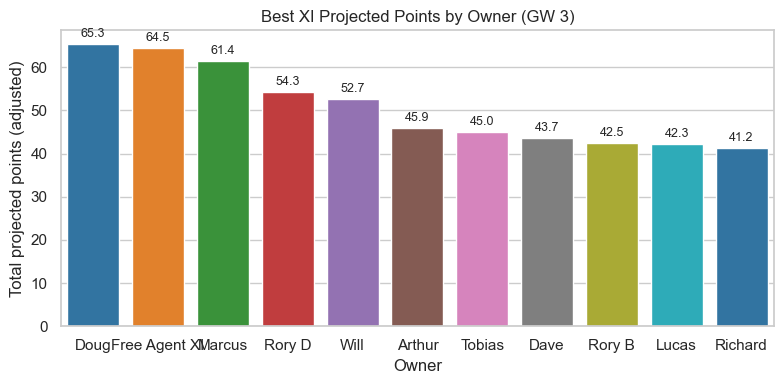

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_owner_summary = owner_summary.copy()

sns.barplot(
    data=plot_owner_summary,
    x='owner_name',
    y='predicted_points_adj_sum',
    hue='owner_name',
    legend=False,
    ax=ax,
    palette='tab10',
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)

ax.set_title(f'Best XI Projected Points by Owner (GW {latest_gw})')
ax.set_xlabel('Owner')
ax.set_ylabel('Total projected points (adjusted)')
plt.xticks(rotation=0)
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'owner_best_xi_gw{latest_gw}.png', dpi=200)

## Shareable Plots

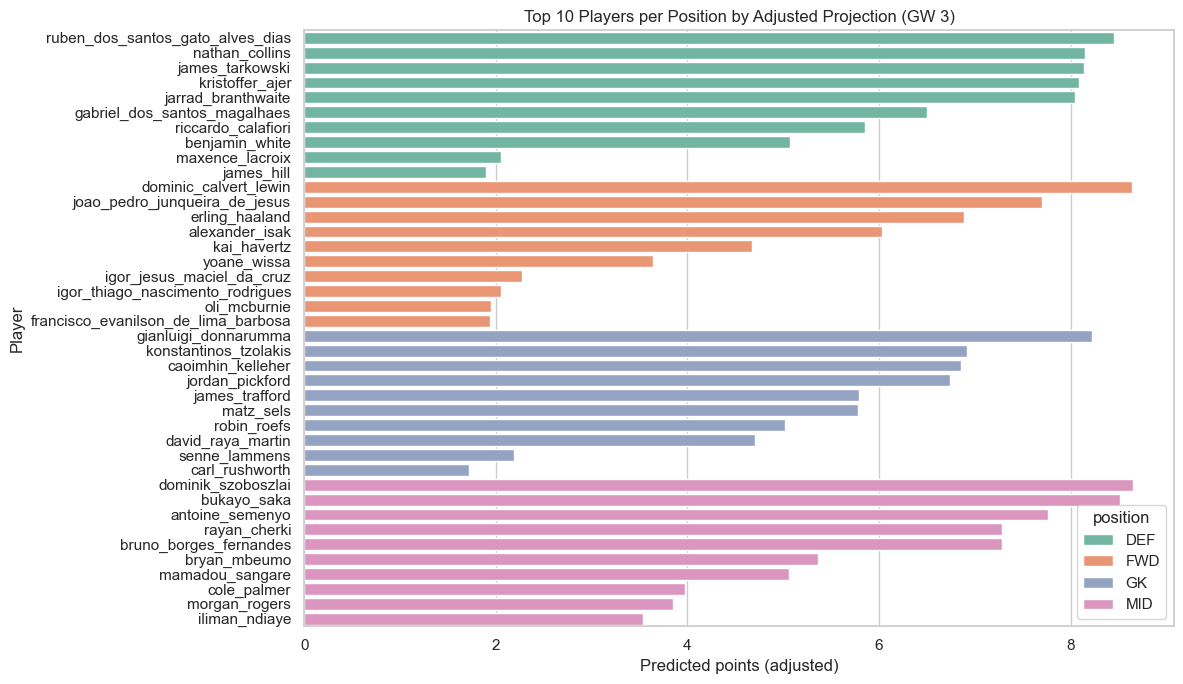

In [27]:
plot_df = (
    df_sorted
    .groupby('position', group_keys=False)
    .head(10)
    .copy()
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=plot_df.sort_values(['position', 'predicted_points_adj'], ascending=[True, False]),
    x='predicted_points_adj',
    y='full_name',
    hue='position',
    dodge=False,
    ax=ax,
    palette='Set2',
)
ax.set_title(f'Top 10 Players per Position by Adjusted Projection (GW {latest_gw})')
ax.set_xlabel('Predicted points (adjusted)')
ax.set_ylabel('Player')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'top10_by_position_gw{latest_gw}.png', dpi=200)

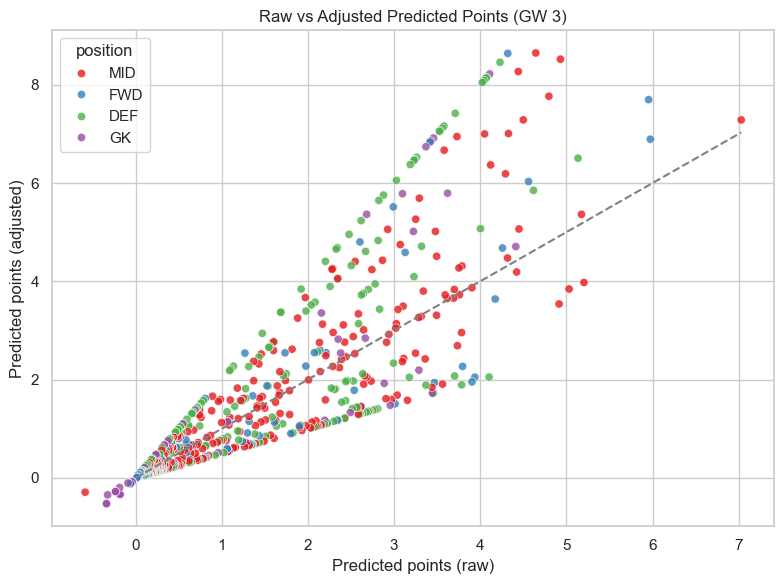

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df_sorted,
    x='predicted_points',
    y='predicted_points_adj',
    hue='position',
    alpha=0.8,
    ax=ax,
    palette='Set1',
)
ax.plot([0, df_sorted['predicted_points'].max()], [0, df_sorted['predicted_points'].max()], linestyle='--', color='grey')
ax.set_title(f'Raw vs Adjusted Predicted Points (GW {latest_gw})')
ax.set_xlabel('Predicted points (raw)')
ax.set_ylabel('Predicted points (adjusted)')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'raw_vs_adjusted_gw{latest_gw}.png', dpi=200)

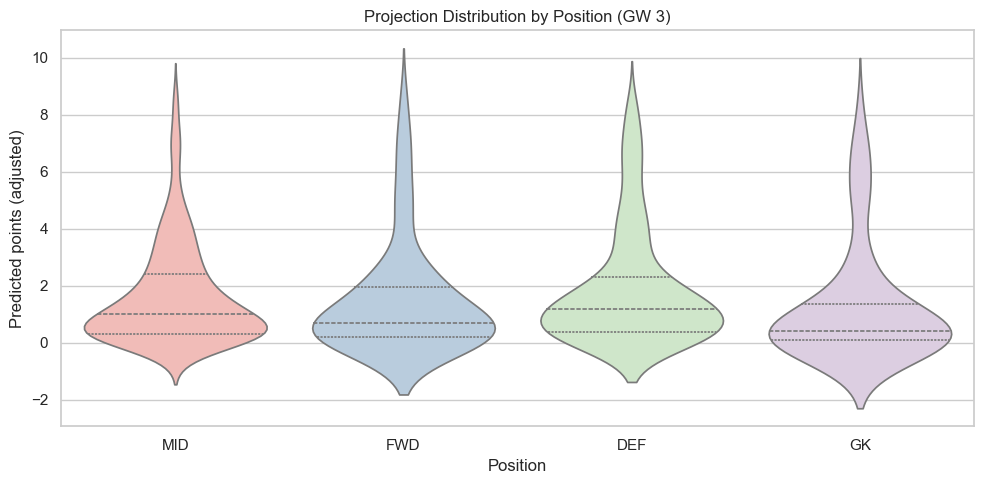

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=df_sorted,
    x='position',
    y='predicted_points_adj',
    inner='quartile',
    hue='position',
    legend=False,
    ax=ax,
    palette='Pastel1',
)
ax.set_title(f'Projection Distribution by Position (GW {latest_gw})')
ax.set_xlabel('Position')
ax.set_ylabel('Predicted points (adjusted)')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'distribution_by_position_gw{latest_gw}.png', dpi=200)

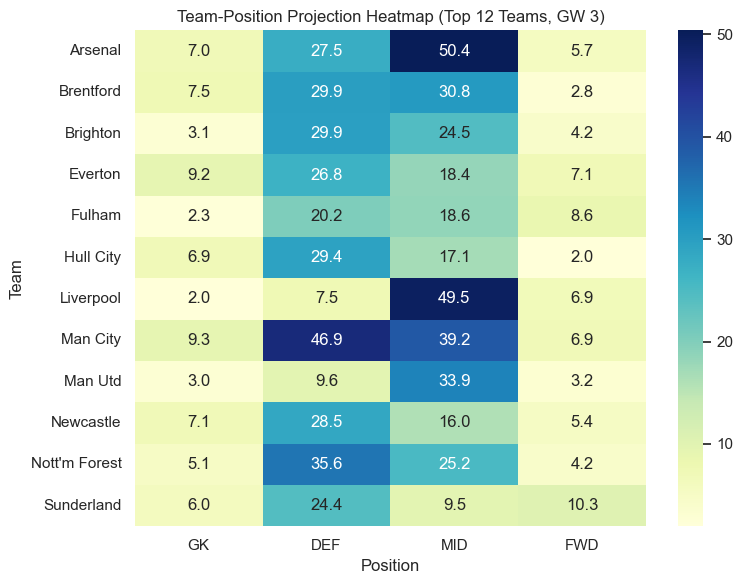

In [30]:
team_pos = (
    df_sorted
    .groupby(['team', 'position'], as_index=False)['predicted_points_adj']
    .sum()
)

team_total = team_pos.groupby('team', as_index=False)['predicted_points_adj'].sum()
top_teams = team_total.sort_values('predicted_points_adj', ascending=False).head(12)['team']
heat_df = team_pos[team_pos['team'].isin(top_teams)].pivot(index='team', columns='position', values='predicted_points_adj').fillna(0)
heat_df = heat_df[['GK', 'DEF', 'MID', 'FWD']]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heat_df, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax)
ax.set_title(f'Team-Position Projection Heatmap (Top 12 Teams, GW {latest_gw})')
ax.set_xlabel('Position')
ax.set_ylabel('Team')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'team_position_heatmap_gw{latest_gw}.png', dpi=200)

In [31]:
share_cols = ['full_name', 'position', 'team', 'owner_name', 'predicted_points', 'predicted_points_adj',
              'predicted_points_adj_3gw', 'predicted_points_adj_6gw', 'fixture_diff_index']
share_table = df_sorted[share_cols].head(25).copy()
share_table

,full_name,position,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,bruno_borges_fernandes,MID,Man Utd,Lucas,7.028292,7.283995,8.920713,8.611228,1.036382
1,erling_haaland,FWD,Man City,Rory D,5.973687,6.891915,9.849672,9.050447,1.153712
2,joao_pedro_junqueira_de_jesus,FWD,Chelsea,Tobias,5.954611,7.696663,9.177904,9.491910,1.292555
3,cole_palmer,MID,Chelsea,Richard,5.203419,3.975260,4.275992,6.156497,0.763971
4,bryan_mbeumo,MID,Man Utd,Rory B,5.174199,5.362447,6.569092,6.335679,1.036382
5,gabriel_dos_santos_magalhaes,DEF,Arsenal,Doug,5.134538,6.505444,6.989424,8.453847,1.266997
6,morgan_rogers,MID,Chelsea,Dave,5.031000,3.843537,4.134150,5.951355,0.763971
7,bukayo_saka,MID,Arsenal,Arthur,4.930232,8.520015,6.747308,6.367934,1.728116
8,iliman_ndiaye,MID,Everton,Lucas,4.914721,3.538381,5.718255,4.756260,0.719956
9,antoine_semenyo,MID,Man City,Dave,4.796598,7.766188,6.026175,7.597857,1.619104


In [32]:
if EXPORT_FIGURES:
    print(f'Saved figures to: {FIG_DIR.resolve()}')
else:
    print('Set EXPORT_FIGURES = True to save PNG charts for sharing.')

Set EXPORT_FIGURES = True to save PNG charts for sharing.


## Historical Backtest: Predicted vs Actual (All GWs)

In [33]:
import re
import sys
import requests

sys.path.append(str(Path('../..').resolve()))
from wrangle_data_funcs import clean_name

predictions_dir = Path('..') / 'predictions'
pred_files = sorted(predictions_dir.glob('predicted_gw[0-9]*.csv'))

gw_file_pairs = []
for file_path in pred_files:
    if file_path.name.endswith('_simple.csv'):
        continue
    match = re.search(r'predicted_gw(\d+)\.csv$', file_path.name)
    if match:
        gw_file_pairs.append((int(match.group(1)), file_path))

gw_file_pairs = sorted(gw_file_pairs, key=lambda x: x[0])
print(f'Found GW prediction files: {len(gw_file_pairs)}')

bootstrap = requests.get('https://fantasy.premierleague.com/api/bootstrap-static/', timeout=20).json()
name_by_element = {}
for elem in bootstrap['elements']:
    full_name = clean_name(f"{elem['first_name']}_{elem['second_name']}")
    name_by_element[elem['id']] = full_name

def load_actual_points_for_gw_from_api(gw):
    event_live = requests.get(f'https://fantasy.premierleague.com/api/event/{gw}/live/', timeout=20).json()
    rows = []
    for item in event_live.get('elements', []):
        element_id = item.get('id')
        full_name = name_by_element.get(element_id)
        if full_name is None:
            continue
        total_points = item.get('stats', {}).get('total_points', np.nan)
        rows.append({'full_name': full_name, 'actual_points': total_points})

    actual_gw_df = pd.DataFrame(rows)
    if actual_gw_df.empty:
        raise ValueError(f'No actual rows returned from FPL API for GW {gw}')

    return actual_gw_df

backtest_frames = []
skipped_gws = []
for gw, file_path in gw_file_pairs:
    pred_gw_df = pd.read_csv(file_path)
    if 'predicted_points_adj' not in pred_gw_df.columns:
        pred_gw_df['predicted_points_adj'] = pred_gw_df['predicted_points']

    try:
        actual_gw_df = load_actual_points_for_gw_from_api(gw)
    except Exception as exc:
        skipped_gws.append((gw, str(exc)))
        continue

    merged = pred_gw_df.merge(actual_gw_df, on='full_name', how='inner')
    if merged.empty:
        skipped_gws.append((gw, 'No name overlap between prediction and actual files'))
        continue

    merged['gw'] = gw
    backtest_frames.append(
        merged[['gw', 'full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'actual_points']]
    )

backtest_df = pd.concat(backtest_frames, ignore_index=True) if backtest_frames else pd.DataFrame()
print(f'Total merged player-GW rows: {len(backtest_df):,}')
if skipped_gws:
    print(f'Skipped GWs: {[gw for gw, _ in skipped_gws]}')

if not backtest_df.empty:
    backtest_df['error_raw'] = backtest_df['predicted_points'] - backtest_df['actual_points']
    backtest_df['error_adj'] = backtest_df['predicted_points_adj'] - backtest_df['actual_points']
    backtest_df['abs_error_raw'] = backtest_df['error_raw'].abs()
    backtest_df['abs_error_adj'] = backtest_df['error_adj'].abs()

backtest_df.head()

Found GW prediction files: 37
Total merged player-GW rows: 609
Skipped GWs: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]


,gw,full_name,position,team,predicted_points,predicted_points_adj,actual_points,error_raw,error_adj,abs_error_raw,abs_error_adj
0,2,aaron_anselmino,DEF,Chelsea,0.782188,0.391094,0,0.782188,0.391094,0.782188,0.391094
1,2,aaron_hickey,DEF,Brentford,1.512935,3.025870,1,0.512935,2.025870,0.512935,2.025870
2,2,abdoul_ouattara,DEF,Ipswich Town,0.947001,1.894002,1,-0.052999,0.894002,0.052999,0.894002
3,2,abdukodir_khusanov,DEF,Man City,3.211374,6.422748,2,1.211374,4.422748,1.211374,4.422748
4,2,abdul_fatawu,MID,Ipswich Town,2.414172,1.984991,4,-1.585828,-2.015009,1.585828,2.015009


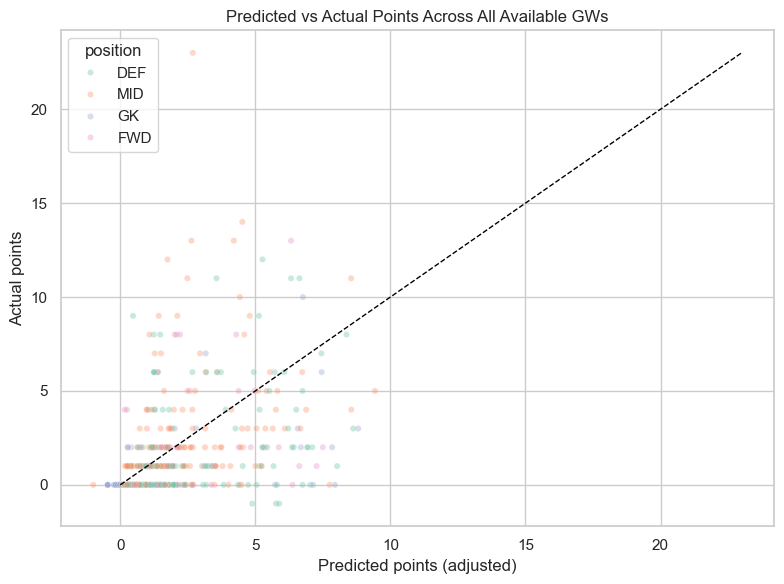

In [34]:
if backtest_df.empty:
    print('No backtest rows available. Check BACKTEST_YEAR and prediction files.')
else:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(
        data=backtest_df,
        x='predicted_points_adj',
        y='actual_points',
        hue='position',
        alpha=0.35,
        s=20,
        ax=ax,
        palette='Set2',
    )

    max_axis = max(backtest_df['predicted_points_adj'].max(), backtest_df['actual_points'].max(), 1)
    ax.plot([0, max_axis], [0, max_axis], linestyle='--', color='black', linewidth=1)
    ax.set_title(f'Predicted vs Actual Points Across All Available GWs')
    ax.set_xlabel('Predicted points (adjusted)')
    ax.set_ylabel('Actual points')
    plt.tight_layout()

    if EXPORT_FIGURES:
        fig.savefig(FIG_DIR / 'pred_vs_actual_all_gws.png', dpi=200)

,gw,mae_raw,mae_adj,rmse_raw,rmse_adj,corr_adj,n_players
0,2,1.269875,1.471447,2.139009,2.495223,0.453176,609


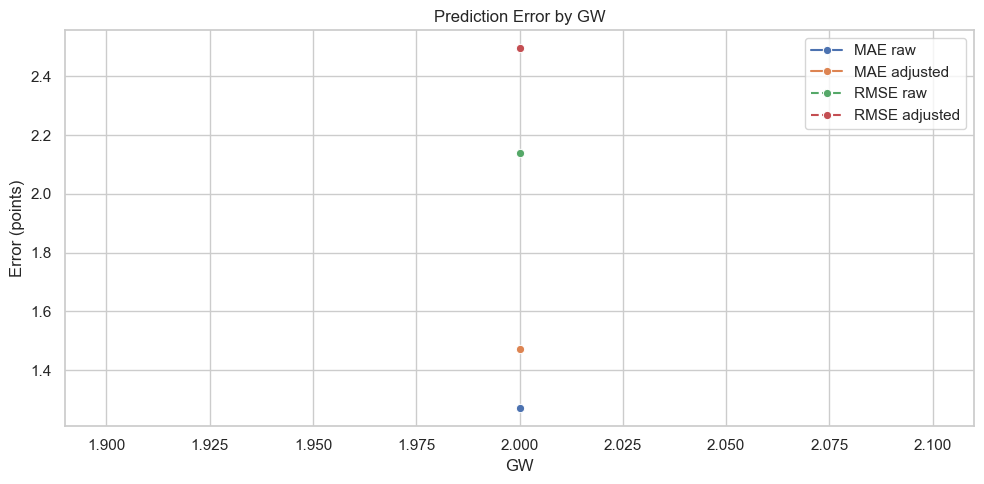

In [35]:
if backtest_df.empty:
    print('No backtest rows available. Skipping GW metric plots.')
else:
    gw_metrics = (
        backtest_df.groupby('gw', as_index=False)
        .agg(
            mae_raw=('abs_error_raw', 'mean'),
            mae_adj=('abs_error_adj', 'mean'),
            rmse_raw=('error_raw', lambda x: np.sqrt(np.mean(np.square(x)))),
            rmse_adj=('error_adj', lambda x: np.sqrt(np.mean(np.square(x)))),
            corr_adj=('predicted_points_adj', lambda x: x.corr(backtest_df.loc[x.index, 'actual_points'])),
            n_players=('full_name', 'count'),
        )
    )

    display(gw_metrics)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.lineplot(data=gw_metrics, x='gw', y='mae_raw', marker='o', label='MAE raw', ax=ax)
    sns.lineplot(data=gw_metrics, x='gw', y='mae_adj', marker='o', label='MAE adjusted', ax=ax)
    sns.lineplot(data=gw_metrics, x='gw', y='rmse_raw', marker='o', label='RMSE raw', ax=ax, linestyle='--')
    sns.lineplot(data=gw_metrics, x='gw', y='rmse_adj', marker='o', label='RMSE adjusted', ax=ax, linestyle='--')
    ax.set_title('Prediction Error by GW')
    ax.set_xlabel('GW')
    ax.set_ylabel('Error (points)')
    plt.tight_layout()

    if EXPORT_FIGURES:
        fig.savefig(FIG_DIR / 'prediction_error_by_gw.png', dpi=200)

### What Is corr_adj?

`corr_adj` is the Pearson correlation between `predicted_points_adj` and `actual_points` within each GW.

- `corr_adj` near `1.0`: your model ranked players very well that week.
- `corr_adj` near `0.0`: weak relationship between predictions and outcomes.
- `corr_adj` below `0.0`: rankings were directionally wrong that week.

This is most useful for judging ranking quality, not absolute error size.

,gw,corr_adj
0,2,0.453176


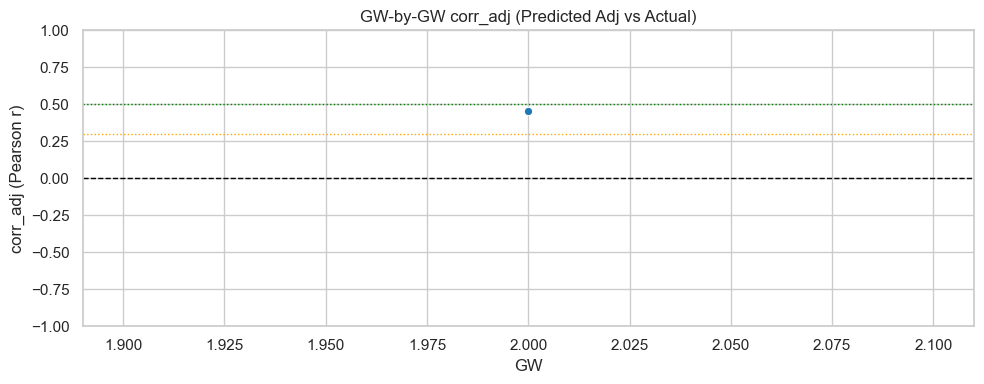

In [36]:
if backtest_df.empty:
    print('No backtest rows available. Skipping corr_adj plot.')
else:
    corr_plot_df = gw_metrics[['gw', 'corr_adj']].dropna().copy()

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.lineplot(data=corr_plot_df, x='gw', y='corr_adj', marker='o', ax=ax, color='#1f77b4')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.axhline(0.5, color='green', linestyle=':', linewidth=1)
    ax.axhline(0.3, color='orange', linestyle=':', linewidth=1)
    ax.set_ylim(-1, 1)
    ax.set_title('GW-by-GW corr_adj (Predicted Adj vs Actual)')
    ax.set_xlabel('GW')
    ax.set_ylabel('corr_adj (Pearson r)')
    plt.tight_layout()

    display(corr_plot_df)

    if EXPORT_FIGURES:
        fig.savefig(FIG_DIR / 'corr_adj_by_gw.png', dpi=200)